## **Ridge Regularization**

### **Topic Roadmap**

 **1. Imports & Dataset Preparation**

 **2. Baseline Linear Regression**

 **3. Ridge Regression Implementation**

 **4. Visualizing Regularization Effects**

### **1. Imports & Dataset Preparation**

Import essential libraries, load the diabetes dataset, and split it into training and testing sets.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Load diabetes dataset
data = load_diabetes()
X = data.data
y = data.target

# Create training and testing splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

### **2. Baseline Linear Regression**

Train a standard Ordinary Least Squares Linear Regression model to establish a performance baseline.

Evaluate the model using $R^2$ score and Root Mean Squared Error (RMSE).

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Initialize and train the baseline model
L = LinearRegression()
L.fit(X_train, y_train)

# Evaluate baseline performance
y_pred = L.predict(X_test)
print("Linear Regression R2 score:", r2_score(y_test, y_pred))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Linear Regression R2 score: 0.5188113124539249
Linear Regression RMSE: 48.72713760953252


### **3. Ridge Regression Implementation**

Train a Ridge Regression model to demonstrate how $L2$ regularization shrinks the coefficients.

The model is initialized with a high penalty parameter ($\alpha=100000$) to heavily regularize the weights.

In [3]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge model
R = Ridge(alpha=100000)
R.fit(X_train, y_train)

# Evaluate Ridge performance
y_pred1 = R.predict(X_test)
print("Ridge R2 score:", r2_score(y_test, y_pred1))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))

Ridge R2 score: -0.00042490200441935855
Ridge RMSE: 70.25956272917782


### **4. Visualizing Regularization Effects**

Generate synthetic non-linear data to demonstrate how Ridge regression prevents overfitting in high-degree polynomial models.

The true relationship follows a quadratic equation.

In [4]:
# Generate non-linear synthetic data
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

Create a machine learning pipeline combining degree-16 polynomial features with Ridge regression.

Compare the model predictions across different penalty values ($\alpha \in \{0, 20, 200\}$).

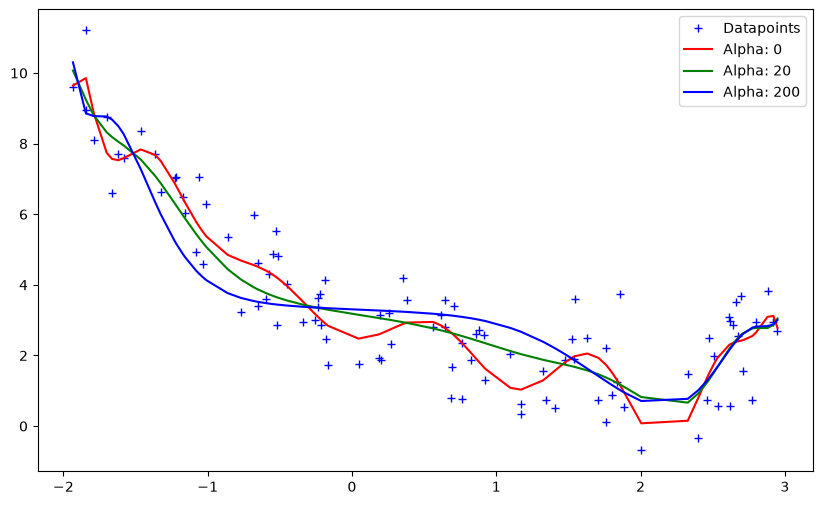

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label=f'Alpha: {alpha}')

plt.legend()
plt.show()

### **Key Revision Notes**

- **Ridge Regression:** Adds an $L2$ penalty to the cost function, which shrinks model coefficients towards zero to prevent overfitting.
- **Alpha Parameter:** Controls the regularization strength. An $\alpha=0$ equates to standard Linear Regression, while an extremely large $\alpha$ (e.g., $100000$) heavily penalizes coefficients, drastically reducing variance but potentially increasing bias.
- **High-Degree Polynomials:** Standard regression overfits complex models (like degree 16 polynomials) by capturing noise. Ridge regression smooths the prediction curve by constraining the polynomial weights.